모델 배포 개론 06  
Last modified : 2026.08  
작성 : 박광석 (모두의연구소)  
수정 : 김지성 ,박기웅(모두의연구소)

In [1]:
# 서버 실행 도우미 — 노트북 맨 처음에 한 번 실행하세요.
# 노트북 안에서 uvicorn 서버를 띄우고 멈추는 함수를 정의합니다.
# Colab의 nest_asyncio 방식 대신, macOS에서도 안정적인 표준 asyncio 루프를 사용합니다.
print("도우미 로딩 중...", flush=True)

import os, sys, asyncio, threading, time, socket, contextlib, subprocess, signal
from pathlib import Path

print("uvicorn import 중...", flush=True)
import uvicorn
print("uvicorn 준비 완료", flush=True)

cwd = Path.cwd()
if (cwd / "DP06.ipynb").exists() or (cwd / "app").exists():
    pass
elif (cwd / "DP06" / "DP06.ipynb").exists():
    os.chdir(cwd / "DP06")
elif cwd.name == "notebooks" and (cwd.parent / "app").exists():
    os.chdir(cwd.parent)

for _d in ("app", "models", "data", "frontend"):
    os.makedirs(_d, exist_ok=True)

_SERVERS = {}

def _port_open(host, port):
    with contextlib.closing(socket.socket()) as s:
        s.settimeout(0.5)
        return s.connect_ex((host, port)) == 0

def _pids_on_port(port):
    """해당 포트를 LISTEN 중인 프로세스 PID 목록을 반환합니다."""
    try:
        out = subprocess.check_output(
            ["lsof", "-nP", f"-iTCP:{port}", "-sTCP:LISTEN", "-t"],
            text=True,
            stderr=subprocess.DEVNULL,
            timeout=2,
        )
    except (subprocess.CalledProcessError, FileNotFoundError, subprocess.TimeoutExpired):
        return []
    pids = []
    for line in out.split():
        try:
            pid = int(line)
        except ValueError:
            continue
        if pid != os.getpid():
            pids.append(pid)
    return pids

def stop_server(port=8000):
    """실행 중인 서버를 멈춥니다. 같은 포트의 다른 프로세스도 종료합니다."""
    entry = _SERVERS.pop(port, None)
    if entry:
        server, thread = entry
        server.should_exit = True
        for _ in range(50):
            if not thread.is_alive():
                break
            time.sleep(0.1)
    for pid in _pids_on_port(port):
        try:
            os.kill(pid, signal.SIGTERM)
        except ProcessLookupError:
            pass
    for _ in range(50):
        if not _port_open("127.0.0.1", port):
            break
        time.sleep(0.1)

def serve_in_thread(app, host="127.0.0.1", port=8000, log_level="warning"):
    """백그라운드에서 uvicorn 서버를 띄웁니다.

    app: FastAPI 객체 또는 'app.main:app' 같은 import 경로.
    같은 포트에 서버가 이미 있으면 먼저 멈추고 새로 띄웁니다.
    """
    stop_server(port)
    if isinstance(app, str):
        sys.modules.pop(app.split(":")[0], None)
    for _ in range(50):
        if not _port_open(host, port):
            break
        time.sleep(0.1)
    if _port_open(host, port):
        print(f"포트 {port}가 아직 사용 중입니다. 다른 서버를 종료한 뒤 다시 실행하세요.")
        return None
    config = uvicorn.Config(app, host=host, port=port, log_level=log_level, loop="asyncio")
    server = uvicorn.Server(config)
    server.install_signal_handlers = lambda: None
    def _run():
        if sys.platform == "win32":
            loop = asyncio.SelectorEventLoop()
        else:
            loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        loop.run_until_complete(server.serve())
    thread = threading.Thread(target=_run, daemon=True)
    thread.start()
    _SERVERS[port] = (server, thread)
    for _ in range(40):
        if getattr(server, "started", False) and _port_open(host, port):
            print(f"서버 실행됨: http://{host}:{port}")
            return server
        if not thread.is_alive():
            break
        time.sleep(0.25)
    print("서버가 시작되지 않았습니다. 위 로그를 확인하세요.")
    return server

print("서버 도우미 준비 완료 (serve_in_thread, stop_server)", flush=True)
print(f"작업 디렉터리: {Path.cwd()}", flush=True)

도우미 로딩 중...
uvicorn import 중...
uvicorn 준비 완료
서버 도우미 준비 완료 (serve_in_thread, stop_server)
작업 디렉터리: /Users/choiseunghyeon/AIFFEL_Quest_ENG/06_Deployment/DP06


# Day 6 — 인증 및 미디어 처리 기초



## 1. API 보안의 필요성: 왜 아무나 호출하면 안 되는가?

---

> **학습 목표**
> - 인증 없는 API의 위험을 구체적인 시나리오로 이해합니다.
> - API 인증 방식의 종류를 파악하고, 이 과정에서 사용할 방식을 알 수 있습니다.

---



### 1.1 지금까지 만든 API의 문제

Day 5에서 완성한 주택 가격 API는 **누구나 호출할 수 있습니다.**
URL만 알면 세상 누구든 추론 요청을 보낼 수 있다는 뜻입니다.

이것이 왜 문제인지 구체적인 시나리오를 살펴보겠습니다.


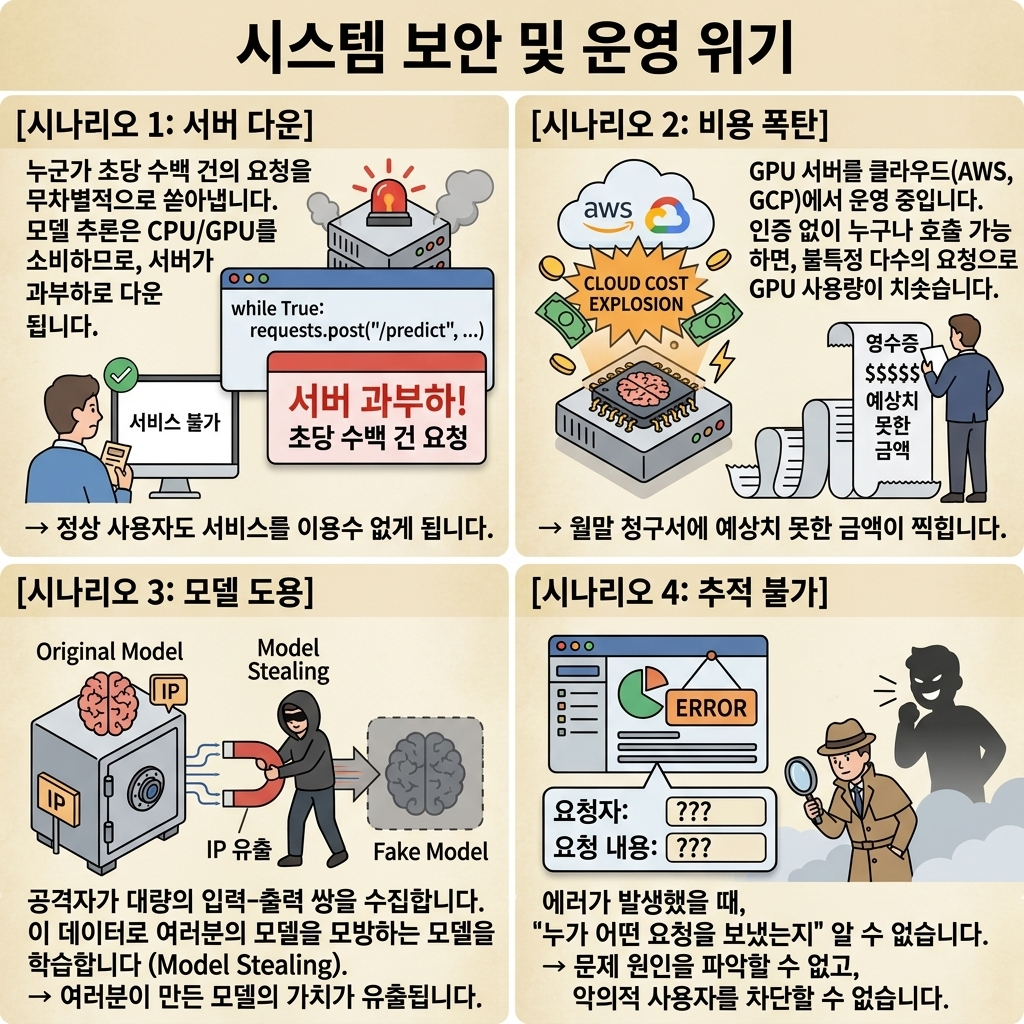


```
[시나리오 1: 서버 다운]
  누군가 while True: requests.post("/predict", ...) 를 실행합니다.
  초당 수백 건의 요청이 쏟아집니다.
  모델 추론은 CPU/GPU를 소비하므로, 서버가 과부하로 다운됩니다.
  → 정상 사용자도 서비스를 이용할 수 없게 됩니다.
```

```
[시나리오 2: 비용 폭탄]
  GPU 서버를 클라우드(AWS, GCP)에서 운영 중입니다.
  인증 없이 누구나 호출 가능하면, 불특정 다수의 요청으로 GPU 사용량이 치솟습니다.
  → 월말 청구서에 예상치 못한 금액이 찍힙니다.
```


```
[시나리오 3: 모델 도용]
  공격자가 대량의 입력-출력 쌍을 수집합니다.
  이 데이터로 여러분의 모델을 모방하는 모델을 학습합니다 (Model Stealing).
  → 여러분이 만든 모델의 가치가 유출됩니다.
```


```
[시나리오 4: 추적 불가]
  에러가 발생했을 때, "누가 어떤 요청을 보냈는지" 알 수 없습니다.
  → 문제 원인을 파악할 수 없고, 악의적 사용자를 차단할 수 없습니다.
```



> 인증은 "누가 호출하는지 확인"하고, "허용된 사용자만 통과"시키는 것입니다.

---



### 1.2 이 과정에서 사용할 인증 방식

인증 방식은 여러 가지가 있습니다. **API Key**는 요청 헤더에 키를 포함하는 가장 간단한 방식이고, **JWT(JSON Web Token)** 는 로그인 후 발급된 토큰을 사용하는 방식, **OAuth 2.0**은 Google이나 GitHub 같은 외부 서비스로 인증을 위임하는 방식입니다. 복잡도와 보안 수준은 API Key < JWT < OAuth 순으로 올라갑니다.

ML 추론 API에서는 **API Key 방식**이 가장 흔합니다. OpenAI, Anthropic, Hugging Face 등 대부분의 ML API가 이 방식을 사용합니다. 사용자 로그인이 필요 없고, 키 하나로 인증과 사용량 추적이 모두 가능하기 때문입니다.

> 이 과정에서는 **API Key 방식**만 다룹니다. 가장 간단하면서도 실무적으로 충분합니다.

---



### ✅ 체크포인트

1. 인증 없는 API가 위험한 이유를 두 가지 이상 설명하세요.
2. API Key 방식이 ML 추론 API에 적합한 이유는 무엇입니까?

---

> **다음 섹션에서는** FastAPI에 API Key 인증을 직접 구현합니다.

## 2. API Key 인증 구현: Header 기반 인증

---

> **학습 목표**
> - FastAPI에서 API Key 인증을 구현할 수 있습니다.
> - 인증이 실패하면 401 에러를 반환하는 구조를 만들 수 있습니다.
> - `Depends()`로 엔드포인트에 인증을 주입하는 패턴을 이해합니다.

---

### 2.1 API Key 인증의 동작 원리


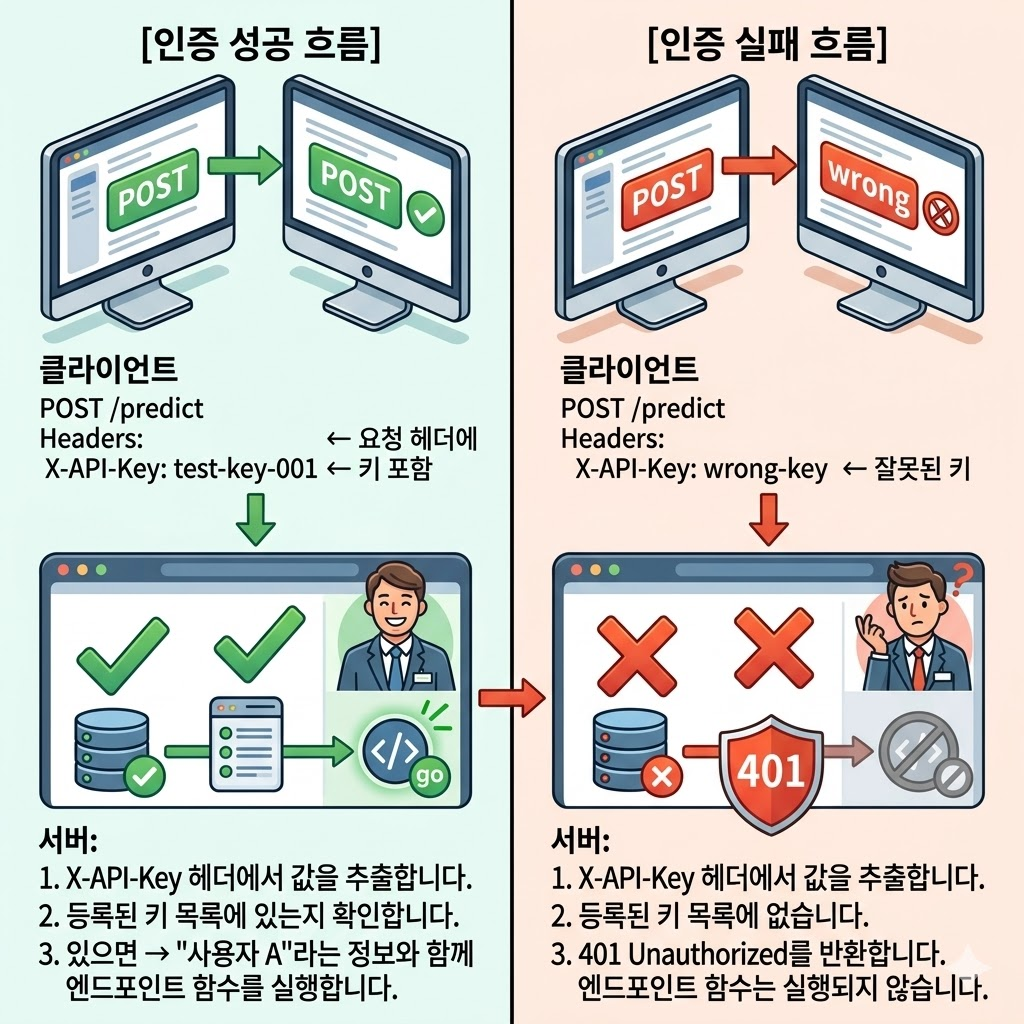


```
[인증 성공 흐름]

클라이언트:
  POST /predict
  Headers:
    X-API-Key: test-key-001          ← 요청 헤더에 키 포함

서버:
  1. X-API-Key 헤더에서 값을 추출합니다.
  2. 등록된 키 목록에 있는지 확인합니다.
  3. 있으면 → "사용자A"라는 정보와 함께 엔드포인트 함수를 실행합니다.
```

```
[인증 실패 흐름]

클라이언트:
  POST /predict
  Headers:
    X-API-Key: wrong-key             ← 잘못된 키

서버:
  1. X-API-Key 헤더에서 값을 추출합니다.
  2. 등록된 키 목록에 없습니다.
  3. 401 Unauthorized를 반환합니다. 엔드포인트 함수는 실행되지 않습니다.
```

---

### 2.2 인증 모듈 구현

In [2]:
%%writefile app/auth.py
"""
Day 6 - API Key 인증
"""
from fastapi import HTTPException, Header

# API Key 설정
# 실무에서는 환경 변수나 시크릿 매니저에서 로드합니다.
# 여기서는 학습 목적으로 하드코딩합니다.
VALID_API_KEYS = {
    "test-key-001": "사용자A",
    "test-key-002": "사용자B",
}


async def verify_api_key(x_api_key: str = Header(None)) -> str:  # *your code* — Header에서 키 추출
    """
    API Key를 검증합니다.

    동작 원리:
      - FastAPI는 파라미터 이름 x_api_key를 HTTP 헤더 X-API-Key에 자동 매핑합니다.
        (언더스코어 _ → 하이픈 -, 대소문자 무시)
      - Header(None): 헤더가 없으면 None이 들어옵니다.

    Returns:
        인증된 사용자 이름 (예: "사용자A")
    Raises:
        HTTPException(401): 키가 없거나 유효하지 않을 때
    """
    if x_api_key is None:
        raise HTTPException(
            status_code=401,                       # *your code* — Unauthorized
            detail="API Key가 필요합니다. X-API-Key 헤더를 포함해 주세요.",
        )

    if x_api_key not in VALID_API_KEYS:
        raise HTTPException(
            status_code=401,
            detail="유효하지 않은 API Key입니다.",
        )

    return VALID_API_KEYS[x_api_key]  # 사용자 이름 반환

Writing app/auth.py


> `Header(None)`이 하는 일:
> - 요청의 `X-API-Key` 헤더 값을 `x_api_key` 변수에 넣습니다.
> - 헤더가 없으면 `None`이 됩니다.
> - FastAPI가 자동으로 `x_api_key` → `X-API-Key`로 매핑합니다.

---



### 2.3 엔드포인트에 인증 적용

인증을 적용하는 방법은 **`Depends(verify_api_key)` 한 줄을 추가**하는 것입니다.

> ⚠️ **아래 코드는 실행하지 마세요.**  
> `Depends(verify_api_key)`가 엔드포인트에 어떻게 적용되는지 보여주는 구조 설명용 코드입니다.  
> 실제 서버 코드는 섹션 6에서 작성합니다.  

```python
from fastapi import FastAPI, Depends
from app.auth import verify_api_key

app = FastAPI()

# 인증 없는 엔드포인트 (기존)
@app.get("/health")
async def health():
    return {"status": "healthy"}

# 인증이 적용된 엔드포인트
@app.post("/predict")
async def predict(
    request: PredictRequest,
    user: str = Depends(verify_api_key),    # ← 이 한 줄이 인증을 적용합니다
):
    # user에는 인증된 사용자 이름("사용자A")이 들어옵니다
    print(f"요청한 사용자: {user}")
    ...
```

`Depends(verify_api_key)`가 하는 일을 단계별로 보면:

```
1. 요청이 들어옵니다.
2. FastAPI가 predict() 함수를 실행하기 전에, verify_api_key()를 먼저 실행합니다.
3. verify_api_key()가 성공하면 → 반환값("사용자A")이 user 변수에 들어갑니다.
   verify_api_key()가 HTTPException을 발생시키면 → predict()는 실행되지 않고 401이 반환됩니다.
```

> `Depends()`는 FastAPI의 **의존성 주입** 기능입니다.
> "이 함수를 실행하기 전에, 먼저 이것을 실행해라"라는 의미입니다.
> 인증 외에도 DB 커넥션 주입, 권한 확인 등 다양하게 활용됩니다.

---



### 2.4 인증 모듈 단독 테스트

서버 없이 인증 로직만 먼저 테스트합니다.

In [3]:
from app.auth import VALID_API_KEYS, verify_api_key
import asyncio

print("등록된 API Key:")
for key, user in VALID_API_KEYS.items():
    print(f"  {key} → {user}")

등록된 API Key:
  test-key-001 → 사용자A
  test-key-002 → 사용자B


In [4]:
# 올바른 키로 테스트
result = await verify_api_key(x_api_key="test-key-001")
print(f"\n올바른 키 → 사용자: {result}")


올바른 키 → 사용자: 사용자A


In [5]:
# 잘못된 키로 테스트
from fastapi import HTTPException

try:
    await verify_api_key(x_api_key="wrong-key")
except HTTPException as e:
    print(f"잘못된 키 → {e.status_code}: {e.detail}")

잘못된 키 → 401: 유효하지 않은 API Key입니다.


In [6]:
# 키 없이 테스트
try:
    await verify_api_key(x_api_key=None)
except HTTPException as e:
    print(f"키 없음 → {e.status_code}: {e.detail}")

키 없음 → 401: API Key가 필요합니다. X-API-Key 헤더를 포함해 주세요.


> 서버를 실행하지 않아도 인증 로직을 테스트할 수 있습니다.
> 실제 서버에서의 통합 테스트는 섹션 6에서 수행합니다.

---

### ✅ 체크포인트

1. `Header(None)`에서 `None`은 어떤 상황에서 `x_api_key`에 들어갑니까?
2. `Depends(verify_api_key)`를 엔드포인트에 추가하면 요청 처리 흐름이 어떻게 바뀝니까?
3. 인증 실패 시 반환하는 HTTP 상태 코드 401의 의미는 무엇입니까?

---

> **다음 섹션에서는** 정형 데이터를 넘어
> 이미지와 텍스트 같은 비정형 데이터를 API에서 처리하는 방법을 배웁니다.

## 3. 비정형 데이터의 세계: 이미지와 텍스트 입력 처리

---

> **학습 목표**
> - 정형 데이터와 비정형 데이터의 차이를 이해합니다.
> - FastAPI의 `UploadFile`을 사용하여 파일 업로드를 구현합니다.

---



### 3.1 정형 vs 비정형 데이터

Day 5에서는 숫자 8개를 JSON으로 보냈습니다. 크기가 고정되어 있고, 데이터 형식이 단순합니다.
하지만 이미지나 텍스트는 다릅니다.

```
Day 5 (정형 데이터):
  입력: {"MedInc": 3.5, "HouseAge": 25, ...}
  크기: 항상 JSON 몇 백 바이트
  처리: 정규화 → 텐서 변환

Day 7 프로젝트 2 (비정형 데이터):
  입력: 이미지 파일 (PNG, JPEG) 또는 텍스트 문자열
  크기: 수 KB ~ 수 MB (가변)
  처리: 파일 검증 → 디코딩 → 리사이징 → 정규화 → 텐서 변환
```

비정형 데이터는 처리 과정이 더 복잡하고, **검증 단계가 추가**됩니다.
파일이 진짜 이미지인지, 크기가 적절한지, 읽을 수 있는지 확인해야 합니다.

---



### 3.2 이미지 전송 방식: Base64 vs UploadFile

Day 2~4에서는 이미지를 Base64로 인코딩하여 JSON에 담아 보냈습니다.
오늘은 **UploadFile**을 사용합니다. 파일을 직접 보내는 방식이고, Swagger UI에서 파일 선택 버튼이 자동으로 나타나 테스트가 편합니다.

두 방식의 판단 기준은 간단합니다. 다른 JSON 데이터와 함께 이미지를 하나의 요청에 담아야 하면 Base64, 파일을 독립적으로 업로드하면 UploadFile입니다. 실무에서는 UploadFile 방식이 더 자주 사용됩니다.

---



### 3.3 FastAPI의 UploadFile 기본 사용법

In [7]:
# UploadFile의 핵심 속성과 메서드를 이해합니다.
# 이 코드는 서버 코드이므로 직접 실행하지 않고, 구조만 파악합니다.

"""
from fastapi import FastAPI, UploadFile, File

app = FastAPI()

@app.post("/upload")
async def upload_image(
    file: UploadFile = File(..., description="업로드할 이미지 파일"),
):
    # file 객체의 주요 속성
    file.filename      # "cat.png" — 원본 파일 이름
    file.content_type   # "image/png" — MIME 타입
    file.size           # 12345 — 파일 크기 (바이트)

    # 파일 내용 읽기 (비동기)
    contents = await file.read()   # bytes 타입으로 반환

    return {"filename": file.filename, "size": len(contents)}
"""

print("UploadFile의 핵심:")
print("  file.filename     → 파일 이름")
print("  file.content_type → MIME 타입 (image/png 등)")
print("  await file.read() → 파일 내용 (bytes)")

UploadFile의 핵심:
  file.filename     → 파일 이름
  file.content_type → MIME 타입 (image/png 등)
  await file.read() → 파일 내용 (bytes)


아래는 구조 설명용 코드입니다. **(실행 X — 서버 코드는 섹션 6에서 작성합니다)**


```python
from fastapi import FastAPI, UploadFile, File

app = FastAPI()

@app.post("/upload")
async def upload_image(
    file: UploadFile = File(..., description="업로드할 이미지 파일"),
):
    file.filename      # "cat.png" — 원본 파일 이름
    file.content_type   # "image/png" — MIME 타입

    contents = await file.read()   # bytes 타입으로 반환

    return {"filename": file.filename, "size": len(contents)}
```



| 속성/메서드 | 설명 | 예시 |
|---|---|---|
| `file.filename` | 파일 이름 | `'cat.png'` |
| `file.content_type` | MIME 타입 | `'image/png'` |
| `await file.read()` | 파일 내용 (bytes) | `b'\x89PNG...'` |

> `UploadFile`을 사용하면 Swagger UI에서 **파일 선택 버튼**이 자동으로 나타납니다.  
> Base64처럼 인코딩 문자열을 직접 붙여넣을 필요가 없습니다.  
> 실제 서버 코드에서의 사용은 섹션 6에서 직접 구현합니다.

---



## 4. 파일 업로드와 안전장치: 크기 제한, 이미지 리사이징

---

> **학습 목표**
> - 파일 업로드 시 크기 제한, 형식 검증 등 안전장치를 구현할 수 있습니다.
> - 이미지를 모델 입력에 맞게 리사이징하고 변환할 수 있습니다.

---



### 4.1 안전장치가 필요한 이유

인증으로 "누가 호출하는지"를 확인했지만, 인증된 사용자도 잘못된 파일을 보낼 수 있습니다.


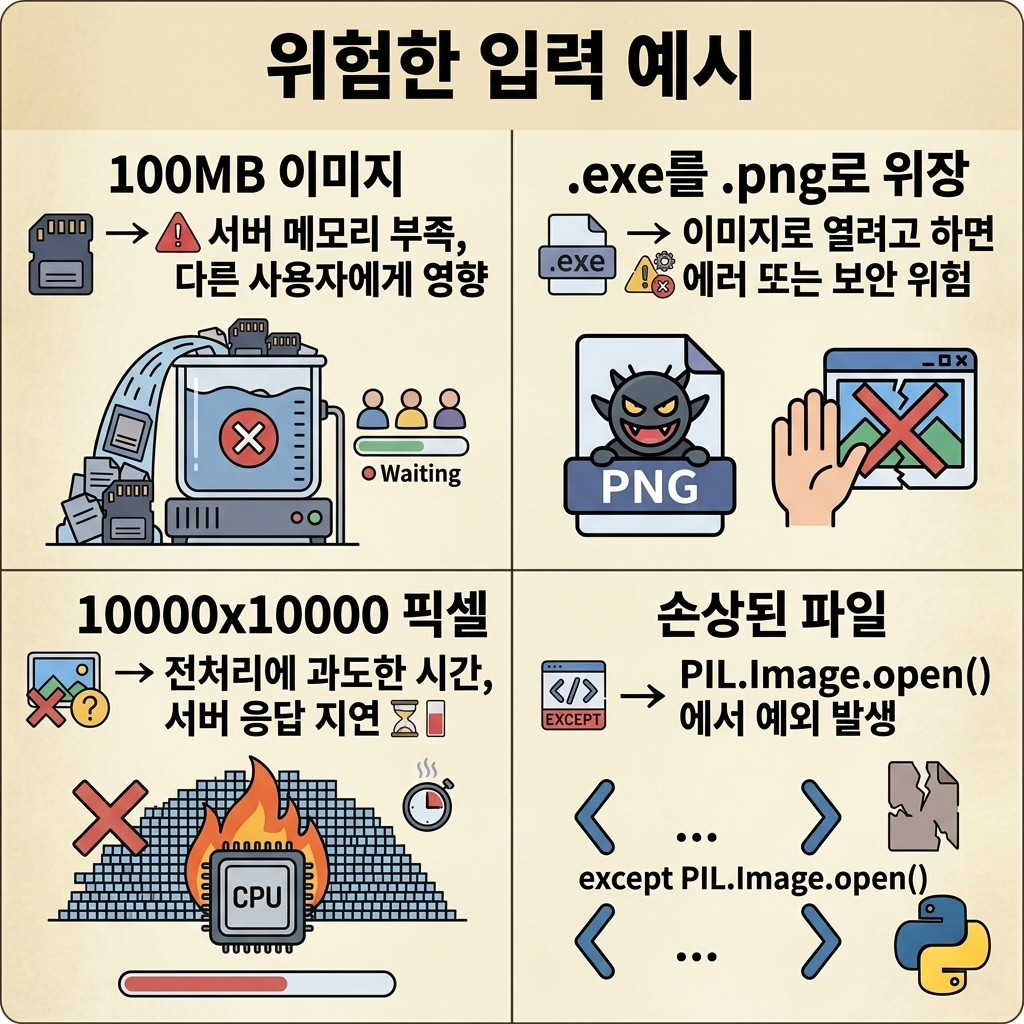


```
위험한 입력 예시:

100MB 이미지         → 서버 메모리 부족, 다른 사용자에게 영향
.exe를 .png로 위장    → 이미지로 열려고 하면 에러 또는 보안 위험
10000x10000 픽셀     → 전처리에 과도한 시간, 서버 응답 지연
손상된 파일           → PIL.Image.open()에서 예외 발생
```

이런 입력을 모델에 도달하기 전에 차단해야 합니다.

---



### 4.2 안전장치 구현

4가지 검증을 순서대로 수행하는 함수를 만듭니다.

In [8]:
%%writefile app/image_utils.py
"""
이미지 업로드 안전장치 + 전처리
"""
from fastapi import UploadFile, HTTPException
from PIL import Image
import io

# 허용 설정
ALLOWED_TYPES = {"image/png", "image/jpeg"}   # 표준 MIME만 (.jpg도 브라우저는 image/jpeg로 전송)
MAX_FILE_SIZE = 5 * 1024 * 1024  # 5MB                     # *your code* — 최대 파일 크기


async def validate_and_read_image(
    file: UploadFile,
    max_size: int = MAX_FILE_SIZE,
    target_size: tuple = (28, 28),
) -> Image.Image:
    """
    업로드된 파일을 검증하고, PIL 이미지로 반환합니다.

    검증 순서:
      1. 파일 타입 검증 → 허용된 형식(PNG, JPEG)만 통과
      2. 파일 크기 검증 → 5MB 이하만 통과
      3. 이미지 디코딩 검증 → 실제로 열 수 있는 이미지만 통과
      4. 리사이징 + 그레이스케일 변환 → 모델 입력 크기에 맞춤
    """

    # ─── 1. 파일 타입 검증 (1차 거름망) ─────────────
    # content_type은 클라이언트가 보낸 MIME 타입이라 *위조될 수 있습니다*.
    # 예: .exe를 .png로 바꿔 올리면 보통 image/png로 전송돼 이 단계는 통과합니다.
    # 따라서 이건 text/plain 같은 명백히 엉뚱한 형식을 싸게 걸러내는 1차 방어이고,
    # 위장 파일의 진짜 차단은 아래 3단계(PIL 디코딩)가 담당합니다.
    if file.content_type not in ALLOWED_TYPES:               # *your code* — 타입 체크
        raise HTTPException(
            status_code=400,
            detail=f"지원하지 않는 파일 형식입니다: {file.content_type}. "
                   f"허용 형식: {ALLOWED_TYPES}",
        )

    # ─── 2. 파일 크기 검증 ─────────────────────────
    # await file.read()로 파일을 "다 읽은 뒤" 크기를 잰다는 점에 주의합니다.
    # 즉 이 검증은 거대한 파일이 서버에 끝까지 전송·적재되는 것 자체를 막지는 못하고,
    # 다 받은 뒤에 거부하는 방식입니다. (단, Starlette은 일정 크기를 넘으면 메모리 대신
    #  디스크 임시 파일로 스풀링하므로 RAM이 통째로 터지지는 않습니다.)
    # "다 받기 전에" 끊으려면 리버스 프록시(nginx client_max_body_size 등)나
    #  업로드 스트림을 청크 단위로 읽는 방식을 씁니다 — 여기서는 학습용으로 단순화합니다.
    contents = await file.read()
    if len(contents) > max_size:                             # *your code* — 크기 체크
        raise HTTPException(
            status_code=400,
            detail=f"파일 크기가 {max_size // (1024*1024)}MB를 초과합니다. "
                   f"현재: {len(contents) / (1024*1024):.1f}MB",
        )

    # ─── 3. 이미지 디코딩 검증 ─────────────────────
    # content_type이 image/png여도 파일 내용이 실제로 이미지가 아닐 수 있습니다.
    # PIL로 열어보면서 확인합니다.
    try:
        image = Image.open(io.BytesIO(contents))
    except Exception:
        raise HTTPException(
            status_code=400,
            detail="이미지를 읽을 수 없습니다. 파일이 손상되었을 수 있습니다.",
        )

    # ─── 4. 리사이징 + 그레이스케일 변환 ──────────────
    # 어떤 크기의 이미지가 들어와도 모델 입력에 맞게 변환합니다.
    image = image.convert("L").resize(target_size)           # *your code* — 그레이스케일 + 리사이즈

    return image

Writing app/image_utils.py


각 검증 단계를 정리합니다:

```
단계                 차단하는 위험            실패 시 상태 코드
────────────────────────────────────────────────────────
1. 타입 검증          엉뚱한 MIME (.txt 등)     400
2. 크기 검증          100MB 이미지             400
3. 디코딩 검증        손상·위장 파일 (.exe 등)   400
4. 리사이징          10000x10000 이미지       (자동 변환)
```

> 4번은 에러를 발생시키지 않고, 어떤 크기의 이미지든 모델 입력에 맞게 변환합니다.
> 모든 검증을 통과한 이미지만 모델에 도달합니다.
>
> ⚠️ `.exe`를 `.png`로 위장하면 **1번(타입)은 통과**하지만 **3번(디코딩)에서 걸립니다** — content_type은 클라이언트가 정하는 값이라 위조될 수 있기 때문입니다.
>
> ⚠️ **크기 검증(2번)의 한계**: `await file.read()`로 파일을 *다 읽은 뒤* 크기를 재므로, 거대한 파일이 서버에 끝까지 올라오는 것 자체는 막지 못합니다(다 받은 뒤 거부). 실무에서는 ① 리버스 프록시(nginx `client_max_body_size`)에서 1차로 끊거나 ② 업로드 스트림을 청크 단위로 읽어 한도를 넘는 순간 중단합니다. 이 노트북은 학습용으로 가장 단순한 "읽고 나서 검증"을 사용합니다.

---



### 4.3 안전장치 단독 테스트

서버 없이 `validate_and_read_image`의 로직을 테스트합니다.

In [9]:
from PIL import Image
import io

# 테스트 이미지 생성 (28x28 그레이스케일)
test_img = Image.new("L", (100, 100), color=128)   # 100x100 회색 이미지
buffer = io.BytesIO()
test_img.save(buffer, format="PNG")
test_bytes = buffer.getvalue()

print(f"테스트 이미지 크기: {len(test_bytes)} bytes")
print(f"테스트 이미지 해상도: {test_img.size}")

테스트 이미지 크기: 156 bytes
테스트 이미지 해상도: (100, 100)


In [10]:
# 리사이징 테스트
img = Image.open(io.BytesIO(test_bytes))
img_resized = img.convert("L").resize((28, 28))
print(f"변환 전: {img.size} → 변환 후: {img_resized.size}")

변환 전: (100, 100) → 변환 후: (28, 28)


In [11]:
# 잘못된 파일 테스트
try:
    Image.open(io.BytesIO(b"this is not an image"))
except Exception as e:
    print(f"디코딩 실패: {type(e).__name__}")
# → 이런 경우 validate_and_read_image()가 400 에러를 반환합니다.

디코딩 실패: UnidentifiedImageError


---

### ✅ 체크포인트

1. `UploadFile`과 Base64 방식의 핵심 차이는 무엇입니까?
2. `file.content_type`으로 타입을 검증하는 이유는 무엇입니까?
3. 파일 크기를 제한하지 않으면 어떤 문제가 발생할 수 있습니까?

---

> **다음 섹션에서는** 인증 + 파일 업로드 + 모델 추론을 결합한 API를 완성합니다.

## 5. 추론 파이프라인: 전처리 → 모델 호출 → 후처리

---

> **학습 목표**
> - 이미지 업로드 → 전처리 → 모델 추론 → 결과 반환의 전체 파이프라인을 이해합니다.

---

### 5.1 전체 파이프라인

```
[클라이언트]                              [서버]

POST /predict/image
Headers: X-API-Key: test-key-001     1. API Key 인증 (섹션 2)
Body: multipart/form-data            2. 파일 검증 + 리사이징 (섹션 4)
  └─ file: digit.png                 3. 텐서 변환 + 정규화
         ──────────────▶             4. 모델 추론 (run_in_executor)
                                     5. 후처리
         ◀──────────────             6. JSON 응답
{
  "success": true,
  "predicted_class": "7",
  "confidence": 0.98,
  "user": "사용자A"
}
```

> 위 응답의 `predicted_class` 키는 섹션 6.5~6.7에서 `label`로 바꾸는 연습을 합니다(따라서 최종 응답의 키는 `label`입니다).

> 각 단계는 Day 1~5에서 배운 기술의 조합입니다.
> 새로운 것은 1번(인증)과 2번(파일 검증)뿐이고, 나머지는 이미 익숙한 패턴입니다.

---

## 6. 실습: 이미지를 업로드하면 분류 결과를 반환하는 API 만들기

---

> **실습 목표**
> - API Key 인증 + UploadFile + MNIST 모델을 결합한 API를 완성합니다.
> - Swagger UI에서 이미지를 업로드하여 추론 결과를 확인합니다.

---

### 6.1 통합 API 서버 코드

> ⚠️ **Day 6부터 바로 시작했거나, 로컬에서 DP06만 연 경우**
>
> 아래에서 만들 `image_api.py`는 이전 Day에서 만든 파일들을 import 합니다.
> — `model_utils.py`(Day 1), `logger_config.py`·`error_handlers.py`·`middleware.py`(Day 3),
> 그리고 학습된 MNIST 모델이 필요합니다.
> 아래 셀을 실행하면 없는 것만 자동으로 만들어 줍니다. (이미 있으면 그대로 둡니다)

In [12]:
# 이전 Day에서 만든 파일을 확인하고, 없으면 새로 만듭니다.
# (아래에서 만들 image_api.py 가 이 파일들을 import 합니다)
import os

for _d in ('app', 'models', 'data'):
    os.makedirs(_d, exist_ok=True)

BACKEND_FILES = {}

BACKEND_FILES["app/model_utils.py"] = r'''import torch
import torch.nn as nn
from torchvision import transforms

class SimpleClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64*7*7, 128), nn.ReLU(), nn.Dropout(0.5), nn.Linear(128, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

preprocess = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

CLASS_NAMES = [str(i) for i in range(10)]

def load_model(model_path, num_classes=10):
    model = SimpleClassifier(num_classes=num_classes)
    model.load_state_dict(torch.load(model_path, map_location="cpu", weights_only=True))
    model.eval()
    return model

def predict(model, image_tensor):
    with torch.no_grad():
        output = model(image_tensor)
        probs = torch.softmax(output, dim=1)[0]
        idx = probs.argmax().item()
        return {
            "predicted_class": CLASS_NAMES[idx],
            "confidence": round(probs[idx].item(), 4),
            "probabilities": {CLASS_NAMES[i]: round(probs[i].item(), 4) for i in range(len(CLASS_NAMES))},
        }
'''

BACKEND_FILES["app/logger_config.py"] = r'''"""
Day 3 - 로깅 설정
"""
import logging
import sys


def setup_logger(name: str = "ml_api", level: str = "INFO") -> logging.Logger:
    """콘솔 로거를 설정합니다."""
    logger = logging.getLogger(name)
    logger.setLevel(getattr(logging, level))

    if logger.handlers:
        return logger

    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setLevel(logging.DEBUG)

    formatter = logging.Formatter(
        fmt="%(asctime)s %(levelname)-8s [%(name)s] %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )
    console_handler.setFormatter(formatter)
    logger.addHandler(console_handler)

    return logger'''

BACKEND_FILES["app/error_handlers.py"] = r'''"""
Day 3 - 글로벌 에러 핸들러
"""
import traceback
import logging

from fastapi import FastAPI, Request
from fastapi.responses import JSONResponse

logger = logging.getLogger("ml_api")


def register_error_handlers(app: FastAPI):
    """FastAPI 앱에 글로벌 에러 핸들러를 등록합니다."""

    @app.exception_handler(Exception)
    async def general_error_handler(request: Request, exc: Exception):
        """모든 예외를 잡아서 안전한 응답을 반환합니다."""
        logger.error(
            f"에러 발생: {type(exc).__name__}: {exc}\n"
            f"경로: {request.method} {request.url}\n"
            f"스택 트레이스:\n{traceback.format_exc()}"
        )
        return JSONResponse(
            status_code=500,
            content={
                "success": False,
                "error": "서버 내부 오류가 발생했습니다.",
            }
            # ⚠️ 클라이언트에게는 상세 정보를 노출하지 않습니다.
            # 상세 정보는 서버 로그에만 기록됩니다.
        )'''

BACKEND_FILES["app/middleware.py"] = r'''"""
Day 3 - 요청/응답 로깅 미들웨어
모든 요청의 메서드, 경로, 응답 시간, 상태 코드를 자동 로깅합니다.
"""
import time
import logging
from fastapi import Request
from starlette.middleware.base import BaseHTTPMiddleware

logger = logging.getLogger("ml_api")


class RequestLoggingMiddleware(BaseHTTPMiddleware):
    async def dispatch(self, request: Request, call_next):
        start_time = time.time()
        response = await call_next(request)
        duration = round(time.time() - start_time, 3)

        log_message = (
            f"{request.method} {request.url.path} "
            f"→ {response.status_code} "
            f"({duration}s)"
        )

        if response.status_code >= 500:
            logger.error(log_message)
        elif response.status_code >= 400:
            logger.warning(log_message)
        else:
            logger.info(log_message)

        response.headers["X-Process-Time"] = str(duration)
        return response'''

for _path, _body in BACKEND_FILES.items():
    if os.path.exists(_path):
        print(f"✅ {_path} 있음")
    else:
        print(f"⚠️ {_path} 없음 → 생성합니다.")
        with open(_path, "w", encoding="utf-8") as f:
            f.write(_body)

MODEL_PATH = "models/mnist_state_dict.pth"
CANDIDATES = [
    "../DP04/models/mnist_state_dict.pth",
    "../DP03/models/mnist_state_dict.pth",
    "../DP02/models/mnist_state_dict.pth",
]
if os.path.exists(MODEL_PATH):
    print(f"✅ {MODEL_PATH} 있음")
else:
    copied = False
    import shutil
    for src in CANDIDATES:
        if os.path.exists(src):
            shutil.copy2(src, MODEL_PATH)
            print(f"✅ 모델을 복사했습니다: {src} → {MODEL_PATH}")
            copied = True
            break
    if not copied:
            print("⚠️ 모델 파일 없음 → MNIST 모델을 학습합니다. (약 1~2분 소요)")
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torchvision import datasets, transforms
    from torch.utils.data import DataLoader
    from app.model_utils import SimpleClassifier

    _tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    _train = DataLoader(datasets.MNIST("data", train=True, download=True, transform=_tf), batch_size=64, shuffle=True)

    _model = SimpleClassifier(10)
    _opt = optim.Adam(_model.parameters(), lr=1e-3)
    _crit = nn.CrossEntropyLoss()
    _model.train()
    for _epoch in range(2):
        for _i, (_x, _y) in enumerate(_train):
            _opt.zero_grad()
            _loss = _crit(_model(_x), _y)
            _loss.backward()
            _opt.step()
            if (_i + 1) % 300 == 0:
                print(f"  Epoch {_epoch+1}, Batch {_i+1}/{len(_train)}, Loss: {_loss.item():.4f}")
    torch.save(_model.state_dict(), MODEL_PATH)
    print(f"  ✅ {MODEL_PATH} 생성 완료")

print("\n🎉 준비 완료. 다음 셀로 진행하세요.")

⚠️ app/model_utils.py 없음 → 생성합니다.
⚠️ app/logger_config.py 없음 → 생성합니다.
⚠️ app/error_handlers.py 없음 → 생성합니다.
⚠️ app/middleware.py 없음 → 생성합니다.
✅ 모델을 복사했습니다: ../DP04/models/mnist_state_dict.pth → models/mnist_state_dict.pth
Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw

  Epoch 1, Batch 300/938, Loss: 0.1878
  Epoch 1, Batch 600/938, Loss: 0.1016
  Epoch 1, Batch 900/938, Loss: 0.0332
  Epoch 2, Batch 300/938, Loss: 0.1389
  Epoch 2, Batch 600/938, Loss: 0.0196
  Epoch 2, Batch 900/938, Loss: 0.0963
  ✅ models/mnist_state_dict.pth 생성 완료

🎉 준비 완료. 다음 셀로 진행하세요.


In [13]:
%%writefile app/image_api.py
"""
Day 6 - 이미지 분류 API (인증 + 파일 업로드 + MNIST 모델)
"""
import asyncio
from contextlib import asynccontextmanager
from concurrent.futures import ThreadPoolExecutor

import torch
from fastapi import FastAPI, UploadFile, File, Depends, HTTPException
from torchvision import transforms

from app.model_utils import load_model, predict, CLASS_NAMES
from app.auth import verify_api_key
from app.image_utils import validate_and_read_image
from app.logger_config import setup_logger
from app.error_handlers import register_error_handlers
from app.middleware import RequestLoggingMiddleware


# ===== 설정 =====
logger = setup_logger("image_api")

# ===== 모델 로드 =====
MODEL_PATH = "models/mnist_state_dict.pth"
model = None


# 서버 생애주기(lifespan) — 시작 시 모델을 한 번 로드합니다.
# (구버전 @app.on_event("startup")는 최신 FastAPI에서 deprecated → lifespan으로 대체)
@asynccontextmanager
async def lifespan(app: FastAPI):
    global model
    logger.info("MNIST 모델 로드 중...")
    model = load_model(MODEL_PATH)
    logger.info("모델 로드 완료")
    yield
    # 종료 시 정리할 자원이 있으면 여기에 작성합니다.


app = FastAPI(
    title="Image Classification API",
    description="이미지를 업로드하면 숫자(0~9)를 분류하는 API (인증 필요)",
    version="1.0.0",
    lifespan=lifespan,
)

app.add_middleware(RequestLoggingMiddleware)
register_error_handlers(app)

executor = ThreadPoolExecutor(max_workers=4, thread_name_prefix="image")

# 전처리 파이프라인 (PIL → Tensor)
img_transform = transforms.Compose([               # *your code* — transforms.Compose 구성
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])


def run_inference(tensor: torch.Tensor) -> dict:
    if model is None:
        raise RuntimeError("모델이 로드되지 않았습니다")
    return predict(model, tensor)


# ===== 엔드포인트 =====

@app.get("/health", tags=["System"])
async def health_check():
    return {"status": "healthy" if model else "loading"}


@app.post("/predict/image", tags=["Inference"])
async def predict_image(
    file: UploadFile = File(..., description="분류할 이미지 (PNG, JPEG)"),
    user: str = Depends(verify_api_key),                     # *your code* — 인증 적용
):
    """
    이미지를 업로드하면 숫자(0~9)를 분류합니다.
    X-API-Key 헤더에 유효한 API Key가 필요합니다.
    """
    logger.info(f"추론 요청 — 사용자: {user}, 파일: {file.filename}")

    # 1. 파일 검증 + 이미지 로드 (28x28 그레이스케일로 변환)
    image = await validate_and_read_image(file, target_size=(28, 28))  # *your code* — 안전장치 적용

    # 2. 텐서 변환
    tensor = img_transform(image).unsqueeze(0)   # (1, 1, 28, 28)

    # 3. 비동기 추론
    try:
        loop = asyncio.get_running_loop()
        result = await loop.run_in_executor(executor, run_inference, tensor)
    except Exception as e:
        logger.error(f"추론 실패: {e}")
        raise HTTPException(status_code=500, detail=f"추론 실패: {str(e)}")

    logger.info(f"추론 완료 — 결과: {result['predicted_class']}, 확신도: {result['confidence']:.2f}")

    return {
        "success": True,
        "predicted_class": result["predicted_class"],
        "confidence": round(result["confidence"], 4),
        "user": user,
    }

Writing app/image_api.py


---

### 6.2 서버 실행

In [14]:
# CLASS_NAMES가 model_utils.py에 없으면 추가합니다
import os

if not os.path.exists("app/model_utils.py"):
    print("❌ app/model_utils.py 가 없습니다 — 위의 사전 준비 셀을 먼저 실행하세요.")
else:
    with open("app/model_utils.py", "r", encoding="utf-8") as f:
        content = f.read()

    if "CLASS_NAMES" not in content:
        with open("app/model_utils.py", "a", encoding="utf-8") as f:
            f.write("\n\n# MNIST 클래스 이름\nCLASS_NAMES = [str(i) for i in range(10)]\n")
        print("✅ CLASS_NAMES 추가 완료")
    else:
        print("✅ CLASS_NAMES 이미 있음")


✅ CLASS_NAMES 이미 있음


In [15]:
# 서버 실행 (같은 포트에 서버가 떠 있으면 자동으로 멈추고 새로 띄웁니다)
serve_in_thread("app.image_api:app", port=8000)

2026-08-20 12:17:07 INFO     [image_api] MNIST 모델 로드 중...
2026-08-20 12:17:07 INFO     [image_api] 모델 로드 완료
서버 실행됨: http://127.0.0.1:8000


---

### 6.3 테스트 1: 인증 없이 요청 → 401

In [16]:
import requests

# API Key 없이 요청
response = requests.post(
    "http://localhost:8000/predict/image",
    files={"file": ("test.png", b"fake image data", "image/png")},
    # headers 없음 → 인증 실패
)

print(f"상태 코드: {response.status_code}")   # 401
print(f"응답: {response.json()}")

POST /predict/image → 401 (0.001s)


상태 코드: 401
응답: {'detail': 'API Key가 필요합니다. X-API-Key 헤더를 포함해 주세요.'}


---

### 6.4 테스트 2: 잘못된 키 → 401

In [17]:
response = requests.post(
    "http://localhost:8000/predict/image",
    files={"file": ("test.png", b"fake image data", "image/png")},
    headers={"X-API-Key": "wrong-key"},                      # *your code* — 잘못된 키
)

print(f"상태 코드: {response.status_code}")   # 401
print(f"응답: {response.json()}")

POST /predict/image → 401 (0.001s)


상태 코드: 401
응답: {'detail': '유효하지 않은 API Key입니다.'}


---

### 6.5 테스트 3: 올바른 키 + MNIST 이미지 → 성공

In [18]:
with open("app/image_api.py", "r", encoding="utf-8") as f:
    content = f.read()

# 응답 '계약'의 키만 label로 바꾼다 — 내부 키(model_utils의 predicted_class)는 그대로!
# (파일 전체를 무차별 replace하면 result["predicted_class"] 조회까지 깨져 KeyError가 난다)
old = '"predicted_class": result["predicted_class"]'
new = '"label": result["predicted_class"]'
if old in content:
    with open("app/image_api.py", "w", encoding="utf-8") as f:
        f.write(content.replace(old, new))
    print("✅ 응답 키를 label로 변경 (내부 키는 그대로)")
else:
    print("✅ 이미 수정되어 있음")

✅ 응답 키를 label로 변경 (내부 키는 그대로)


In [19]:
# 서버 실행 (같은 포트에 서버가 떠 있으면 자동으로 멈추고 새로 띄웁니다)
serve_in_thread("app.image_api:app", port=8000)

2026-08-20 12:17:08 INFO     [image_api] MNIST 모델 로드 중...
2026-08-20 12:17:08 INFO     [image_api] 모델 로드 완료
서버 실행됨: http://127.0.0.1:8000


In [20]:
try:
    from app import image_api
    print("✅ import 성공")
except Exception as e:
    print(f"❌ import 실패: {e}")

✅ import 성공


In [21]:
with open("app/image_api.py", "r", encoding="utf-8") as f:
    for i, line in enumerate(f, 1):
        if "label" in line.lower() or "predict" in line.lower():
            print(f"{i}: {line.rstrip()}")

12: from app.model_utils import load_model, predict, CLASS_NAMES
62:     return predict(model, tensor)
72: @app.post("/predict/image", tags=["Inference"])
73: async def predict_image(
97:     logger.info(f"추론 완료 — 결과: {result['predicted_class']}, 확신도: {result['confidence']:.2f}")
101:         "label": result["predicted_class"],


In [22]:
from torchvision import datasets
from PIL import Image
import io
import requests

# MNIST 테스트 이미지 가져오기
test_dataset = datasets.MNIST(root="data", train=False, download=True)
test_image, test_label = test_dataset[0]   # 첫 번째 테스트 이미지

# PIL 이미지 → bytes 변환
buf = io.BytesIO()
test_image.save(buf, format="PNG")
image_bytes = buf.getvalue()

print(f"테스트 이미지 정답: {test_label}")

# API 호출
response = requests.post(
    "http://localhost:8000/predict/image",
    files={"file": ("digit.png", image_bytes, "image/png")},
    headers={"X-API-Key": "test-key-001"},                   # *your code* — 올바른 키
)

print(f"상태 코드: {response.status_code}")   # 200
result = response.json()
print(f"예측 결과: {result}")

테스트 이미지 정답: 7
2026-08-20 12:17:09 INFO     [image_api] 추론 요청 — 사용자: 사용자A, 파일: digit.png
2026-08-20 12:17:09 INFO     [image_api] 추론 완료 — 결과: 7, 확신도: 1.00
상태 코드: 200
예측 결과: {'success': True, 'label': '7', 'confidence': 1.0, 'user': '사용자A'}


---

### 6.6 테스트 4: 잘못된 파일 형식 → 400

In [23]:
response = requests.post(
    "http://localhost:8000/predict/image",
    files={"file": ("test.txt", b"this is not an image", "text/plain")},
    headers={"X-API-Key": "test-key-001"},
)

print(f"상태 코드: {response.status_code}")   # 400
print(f"응답: {response.json()}")

2026-08-20 12:17:09 INFO     [image_api] 추론 요청 — 사용자: 사용자A, 파일: test.txt


POST /predict/image → 400 (0.002s)


상태 코드: 400
응답: {'detail': "지원하지 않는 파일 형식입니다: text/plain. 허용 형식: {'image/png', 'image/jpeg'}"}


---

### 6.7 테스트 5: 여러 이미지 연속 테스트

In [24]:
import requests
from torchvision import datasets
from PIL import Image
import io

test_dataset = datasets.MNIST(root="data", train=False, download=True)

print("=== 연속 추론 테스트 (5장) ===\n")

for i in range(5):
    img, label = test_dataset[i]

    buf = io.BytesIO()
    img.save(buf, format="PNG")

    resp = requests.post(
        "http://localhost:8000/predict/image",
        files={"file": (f"digit_{i}.png", buf.getvalue(), "image/png")},
        headers={"X-API-Key": "test-key-001"},
    )

    r = resp.json()
    predicted = r.get("label", "?")
    confidence = r.get("confidence", 0)
    match = "✅" if str(label) == str(predicted) else "❌"

    print(f"  이미지 {i}: 정답={label}, 예측={predicted}, 확신도={confidence:.4f} {match}")

=== 연속 추론 테스트 (5장) ===

2026-08-20 12:17:09 INFO     [image_api] 추론 요청 — 사용자: 사용자A, 파일: digit_0.png
2026-08-20 12:17:09 INFO     [image_api] 추론 완료 — 결과: 7, 확신도: 1.00
  이미지 0: 정답=7, 예측=7, 확신도=1.0000 ✅
2026-08-20 12:17:09 INFO     [image_api] 추론 요청 — 사용자: 사용자A, 파일: digit_1.png
2026-08-20 12:17:09 INFO     [image_api] 추론 완료 — 결과: 2, 확신도: 1.00
  이미지 1: 정답=2, 예측=2, 확신도=1.0000 ✅
2026-08-20 12:17:09 INFO     [image_api] 추론 요청 — 사용자: 사용자A, 파일: digit_2.png
2026-08-20 12:17:09 INFO     [image_api] 추론 완료 — 결과: 1, 확신도: 1.00
  이미지 2: 정답=1, 예측=1, 확신도=1.0000 ✅
2026-08-20 12:17:09 INFO     [image_api] 추론 요청 — 사용자: 사용자A, 파일: digit_3.png
2026-08-20 12:17:09 INFO     [image_api] 추론 완료 — 결과: 0, 확신도: 1.00
  이미지 3: 정답=0, 예측=0, 확신도=1.0000 ✅
2026-08-20 12:17:09 INFO     [image_api] 추론 요청 — 사용자: 사용자A, 파일: digit_4.png
2026-08-20 12:17:09 INFO     [image_api] 추론 완료 — 결과: 4, 확신도: 1.00
  이미지 4: 정답=4, 예측=4, 확신도=1.0000 ✅


---

### 6.8 Swagger UI에서 테스트

```
1. 아래 셀을 실행해 Swagger UI를 띄웁니다 (로컬 Mac은 브라우저에서 http://localhost:8000/docs 가 열립니다)
2. POST /predict/image → Try it out
3. x-api-key 입력란에 test-key-001 입력
4. Choose File → 아무 이미지 선택 (위 셀들이 만든 digit.png 등)
5. Execute → 결과 확인
```

> `Header()`로 정의한 `x_api_key` 파라미터가 Swagger UI에 `x-api-key` 입력란으로 나타납니다. (언더스코어 `_` → 하이픈 `-` 자동 변환)

> ⚠️ **화면이 비어 있거나 계속 로딩만 된다면**
> - 6.2의 서버 실행 셀이 `서버 실행됨`을 출력했는지 먼저 확인하세요.
> - 로컬 Mac에서는 Jupyter iframe 대신 브라우저 탭을 사용하세요.

In [ ]:
# Swagger UI 열기 — Colab은 iframe, 로컬(Mac)은 브라우저 탭
try:
    from google.colab import output as _colab_output
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

DOCS_URL = "http://localhost:8000/docs"

if IN_COLAB:
    from google.colab import output
    print("✅ Swagger UI를 아래에 띄웁니다 (Colab 프록시 → 포트 8000)")
    output.serve_kernel_port_as_iframe(8000, path="/docs", height="800")
else:
    import webbrowser
    print(f"✅ 브라우저에서 엽니다: {DOCS_URL}")
    print("   (Jupyter iframe은 localhost X-Frame 제한으로 비어 보일 수 있습니다)")
    webbrowser.open(DOCS_URL)

✅ 브라우저에서 엽니다: http://localhost:8000/docs
   (Jupyter iframe은 localhost X-Frame 제한으로 비어 보일 수 있습니다)


: 


### 6.9 프로젝트 구조 확인

```
model-serving-course/
├── 📁 app/
│   ├── auth.py                ← 🆕 Day 6: API Key 인증
│   ├── image_utils.py         ← 🆕 Day 6: 이미지 검증/전처리
│   ├── image_api.py           ← 🆕 Day 6: 이미지 분류 API (인증 + 업로드)
│   ├── housing_model.py       ← Day 5
│   ├── housing_schemas.py     ← Day 5
│   ├── housing_api.py         ← Day 5
│   ├── model_utils.py         ← Day 1
│   ├── schemas.py             ← Day 2
│   ├── error_handlers.py      ← Day 3
│   ├── logger_config.py       ← Day 3
│   └── middleware.py          ← Day 3
│
├── 📁 models/
│   ├── mnist_state_dict.pth
│   ├── housing_model.pth
│   └── housing_preprocessing.json
└── ...
```

---

### ✅ Day 6 최종 체크포인트

```
Q1. API Key 인증이 없으면 어떤 위험이 있습니까? (두 가지 이상)
Q2. Depends(verify_api_key)는 엔드포인트 실행 전에 어떤 일을 합니까?
Q3. UploadFile 방식이 Base64보다 편리한 점은 무엇입니까?
Q4. 파일 업로드 시 크기 제한을 하지 않으면 어떤 문제가 생깁니까?
Q5. 이미지를 28x28 그레이스케일로 변환하는 이유는 무엇입니까?
```

---

### 📌 Day 6 요약

```
오늘 한 일:
  ✅ API Key 인증의 필요성을 이해하고 구현했습니다.
  ✅ Depends()를 사용하여 엔드포인트에 인증을 적용했습니다.
  ✅ UploadFile로 이미지 파일 업로드를 구현했습니다.
  ✅ 파일 크기/형식 검증, 이미지 리사이징 등 안전장치를 구현했습니다.
  ✅ 인증 + 파일 업로드 + 모델 추론을 결합한 API를 완성했습니다.
```

### 제출

다음 내역을 MD 파일로 기록, 깃헙에 업로드해주세요 !

1. 섹션 6 수행내역 캡쳐, 6.8은 반드시 포함되어야 합니다  
2. 각 섹션 체크포인트의 답변

수고하셨습니다!